# Proyecto Integrador IV
> E-Commerce Data Pipeline

En este notebook, primero ejecutaremos todos los componentes de nuestro pipeline ELT y luego realizaremos visualizaciones con la información resultante


In [156]:
# Importing the necessary libraries
from pandas import DataFrame
from sqlalchemy import create_engine
from typing import Dict
from pathlib import Path

from src.transform import QueryEnum
from src import config
from src.transform import run_queries
from src.extract import extract
from src.load import load
from src.plots import (
    plot_delivery_date_difference,
    plot_global_amount_order_status,
    plot_real_vs_predicted_delivered_time,
    plot_get_freight_value_weight_relationship,
    plot_orders_per_day_and_holidays_2017,
    plot_revenue_by_month_year,
    plot_revenue_per_state,
    plot_top_10_least_revenue_categories,
    plot_top_10_revenue_categories_ammount,
    plot_top_10_revenue_categories,
    
)

In [157]:
print(dir())  # Muestra todas las variables y funciones definidas


['DataFrame', 'Dict', 'ENGINE', 'In', 'Out', 'Path', 'QueryEnum', '_', '_10', '_11', '_111', '_112', '_113', '_114', '_115', '_116', '_117', '_118', '_12', '_13', '_136', '_137', '_138', '_139', '_14', '_140', '_141', '_142', '_143', '_15', '_16', '_42', '_43', '_44', '_45', '_46', '_47', '_48', '_49', '_75', '_76', '_77', '_78', '_79', '_80', '_81', '_82', '_9', '__', '___', '__annotations__', '__builtin__', '__builtins__', '__doc__', '__loader__', '__name__', '__package__', '__spec__', '__vsc_ipynb_file__', '_dh', '_i', '_i1', '_i10', '_i100', '_i101', '_i102', '_i103', '_i104', '_i105', '_i106', '_i107', '_i108', '_i109', '_i11', '_i110', '_i111', '_i112', '_i113', '_i114', '_i115', '_i116', '_i117', '_i118', '_i119', '_i12', '_i120', '_i121', '_i122', '_i123', '_i124', '_i125', '_i126', '_i127', '_i128', '_i129', '_i13', '_i130', '_i131', '_i132', '_i133', '_i134', '_i135', '_i136', '_i137', '_i138', '_i139', '_i14', '_i140', '_i141', '_i142', '_i143', '_i144', '_i145', '_i146', '_

In [158]:
# Create the database sql file
Path(config.SQLITE_BD_ABSOLUTE_PATH).touch()

# Create the database connection
ENGINE = create_engine(rf"sqlite:///{config.SQLITE_BD_ABSOLUTE_PATH}", echo=False)

### 1. Extract

Aquí estarás extrayendo la información de las fuentes.

In [159]:
import os

csv_folder = config.DATASET_ROOT_PATH
public_holidays_url = config.PUBLIC_HOLIDAYS_URL

# 1. Get the mapping of the csv files to the table names.
csv_table_mapping = config.get_csv_to_table_mapping()

# check if all files exist
for csv_file in csv_table_mapping.keys():
    file_path = os.path.join(csv_folder, csv_file)
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"No such file or directory: '{file_path}'")


# 2. Extract the data from the csv files, holidays and load them into the dataframes.
csv_dataframes = extract(csv_folder, csv_table_mapping, public_holidays_url)




### 2. Load

Usando los diferentes conjuntos de datos proporcionados, almacenarás todo en nuestro Data Warehouse.

In [160]:
load(data_frames=csv_dataframes, database=ENGINE)

### 3. Transform

Aquí transformarás las diferentes consultas en tablas. Hay dos secciones: una con las consultas relacionadas con los ingresos y otra con las consultas relacionadas con las entregas.

##### 3.1 Queries sobre ingresos

In [161]:
query_results: Dict[str, DataFrame] = run_queries(database=ENGINE)

In [162]:
# Transforming the revenue_by_month_year query to a table
revenue_by_month_year = query_results[QueryEnum.REVENUE_BY_MONTH_YEAR.value]
revenue_by_month_year

,month_no,month,Year2016,Year2017,Year2018
0,01,Ene,0.00,138488.04,1115004.18
1,02,Feb,0.00,291908.01,992463.34
2,03,Mar,0.00,449863.60,1159652.12
3,04,Abr,0.00,417788.03,1160785.48
4,05,May,0.00,592918.82,1153982.15
5,06,Jun,0.00,511276.38,1023880.50
6,07,Jul,0.00,592382.92,1066540.75
7,08,Ago,0.00,674396.32,1022425.32
8,09,Sep,252.24,727762.45,4439.54
9,10,Oct,59090.48,779677.88,589.67


In [163]:
# Transforming the top_10_revenue_categories query to a table
top_10_revenue_categories = query_results[QueryEnum.TOP_10_REVENUE_CATEGORIES.value]
top_10_revenue_categories

,Category,Num_order,Revenue
0,beleza_saude,8647,1412089.53
1,relogios_presentes,5493,1264016.98
2,cama_mesa_banho,9272,1225209.26
3,esporte_lazer,7529,1118062.91
4,informatica_acessorios,6529,1032603.65
5,moveis_decoracao,6307,880329.92
6,utilidades_domesticas,5743,758392.25
7,cool_stuff,3559,691680.89
8,automotivo,3809,669319.92
9,ferramentas_jardim,3448,567145.68


In [164]:
# Transforming the top_10_least_revenue_categories query to a table
top_10_least_revenue_categories = query_results[
    QueryEnum.TOP_10_LEAST_REVENUE_CATEGORIES.value
]
top_10_least_revenue_categories

,Category,Num_order,Revenue
0,seguros_e_servicos,2,324.51
1,fashion_roupa_infanto_juvenil,7,598.67
2,cds_dvds_musicais,12,954.99
3,casa_conforto_2,24,1170.58
4,pc_gamer,7,1430.10
5,flores,29,1598.91
6,fraldas_higiene,25,2046.19
7,artes_e_artesanato,23,2184.14
8,la_cuisine,13,2388.54
9,fashion_esporte,26,2657.55


In [165]:
# Transforming the revenue_per_state query to a table
revenue_per_state = query_results[QueryEnum.REVENUE_PER_STATE.value]
revenue_per_state

,customer_state,Revenue
0,SP,5768518.23
1,RJ,2055401.57
2,MG,1818891.67
3,RS,861278.79
4,PR,781708.80
5,SC,595127.78
6,BA,591137.81
7,DF,346123.35
8,GO,334212.35
9,ES,317657.93


##### 3.2 Queries sobre entregas

In [166]:
# Transforming the delivery_date_difference query to a table
delivery_date_difference = query_results[QueryEnum.DELIVERY_DATE_DIFFERENCE.value]
delivery_date_difference

,State,Delivery_Difference
0,MA,-8
1,AL,-8
2,SE,-9
3,ES,-9
4,SP,-10
5,SC,-10
6,PI,-10
7,MS,-10
8,CE,-10
9,BA,-10


In [167]:
# Transforming the real vs predicted delivered time query to a table per month and year
real_vs_estimated_delivered_time = query_results[
    QueryEnum.REAL_VS_ESTIMATED_DELIVERED_TIME.value
]
real_vs_estimated_delivered_time

,month_no,month,Year2016_real_time,Year2017_real_time,Year2018_real_time,Year2016_estimated_time,Year2017_estimated_time,Year2018_estimated_time
0,01,Ene,NaN,8.602918,15.330987,NaN,31.242794,26.683252
1,02,Feb,NaN,10.331250,14.672381,NaN,34.873981,26.104765
2,03,Mar,NaN,11.908795,15.365344,NaN,25.749432,22.558378
3,04,Abr,NaN,12.813702,15.366259,NaN,26.811451,23.011034
4,05,May,NaN,12.943527,11.861215,NaN,24.907252,22.419256
5,06,Jun,NaN,11.679506,11.721084,NaN,24.614169,27.801868
6,07,Jul,NaN,11.289015,9.149208,NaN,23.095980,22.123831
7,08,Ago,NaN,11.000487,8.741144,NaN,23.493587,16.407960
8,09,Sep,NaN,12.487484,40.148743,NaN,22.067024,16.967427
9,10,Oct,14.480048,11.757649,114.608503,55.117775,23.625262,59.408579


In [168]:
# Transforming the global ammount of order status query to a table
global_ammount_order_status = query_results[QueryEnum.GLOBAL_AMMOUNT_ORDER_STATUS.value]
global_ammount_order_status

,order_status,Ammount
0,delivered,96478
1,shipped,1107
2,canceled,625
3,unavailable,609
4,invoiced,314
5,processing,301
6,created,5
7,approved,2


In [169]:
orders_per_day_and_holidays = query_results[
    QueryEnum.ORDERS_PER_DAY_AND_HOLIDAYS_2017.value
]
orders_per_day_and_holidays

,date,order_count,holiday
0,2017-01-05,32,False
1,2017-01-06,4,False
2,2017-01-07,4,False
3,2017-01-08,6,False
4,2017-01-09,5,False
...,...,...,...
356,2017-12-27,167,False
357,2017-12-28,146,False
358,2017-12-29,135,False
359,2017-12-30,97,False


In [170]:
freight_value_weight_relationship = query_results[
    QueryEnum.GET_FREIGHT_VALUE_WEIGHT_RELATIONSHIP.value
]

### 4. Graficas de las tablas resultantes

Ahora, crearemos gráficos a partir de las diferentes consultas.

c:\Users\fisca\OneDrive\Documentos\PROYECTO4\proyecto\proyecto_integrador\src\plots.py:41: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



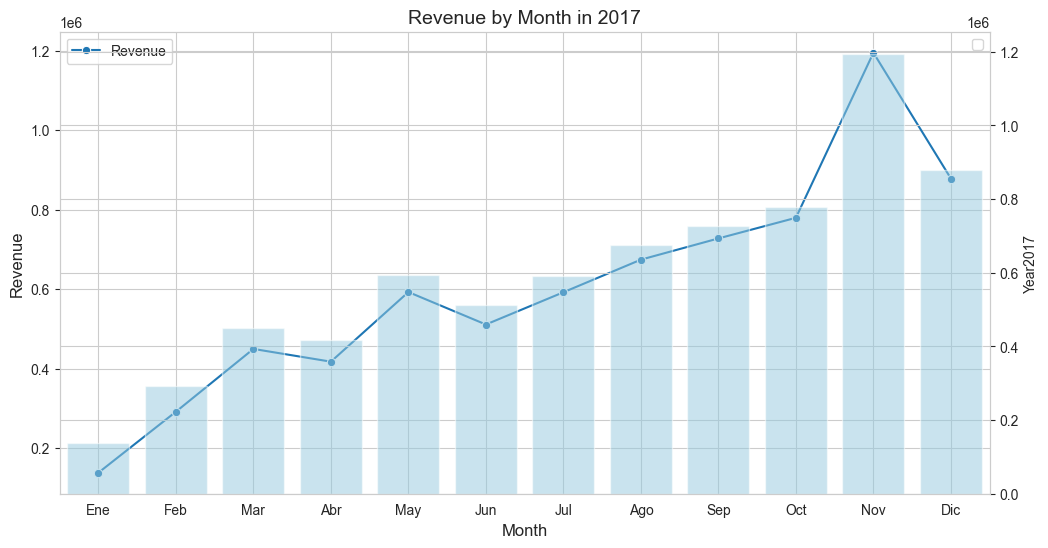

In [171]:
plot_revenue_by_month_year(revenue_by_month_year, 2017)

In [172]:
plot_top_10_revenue_categories(top_10_revenue_categories)

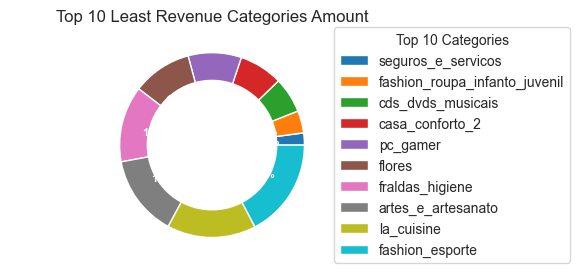

In [173]:
plot_top_10_least_revenue_categories(top_10_least_revenue_categories)

In [174]:
plot_revenue_per_state(revenue_per_state)

In [175]:
print(delivery_date_difference.columns)

Index(['State', 'Delivery_Difference'], dtype='object')


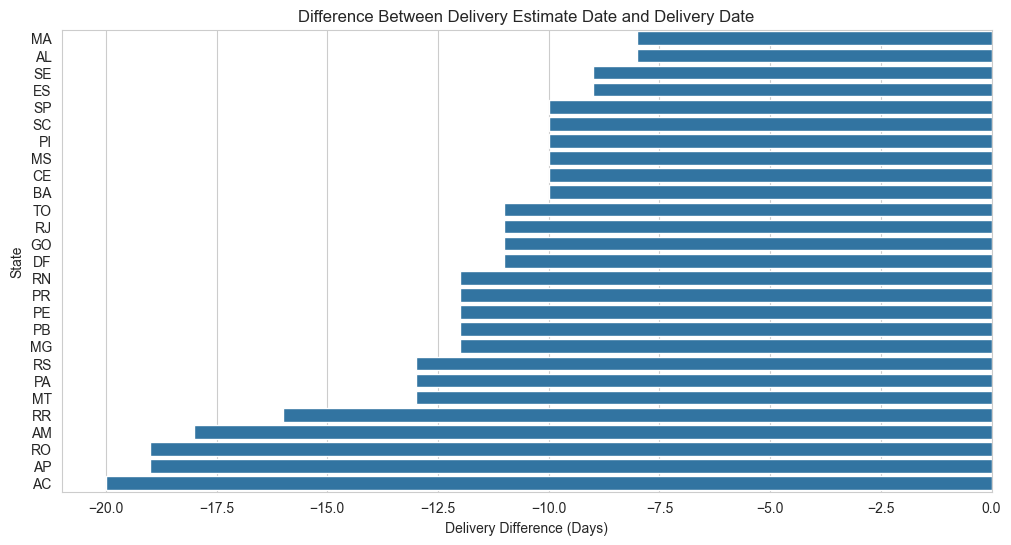

In [176]:
plot_delivery_date_difference(delivery_date_difference)

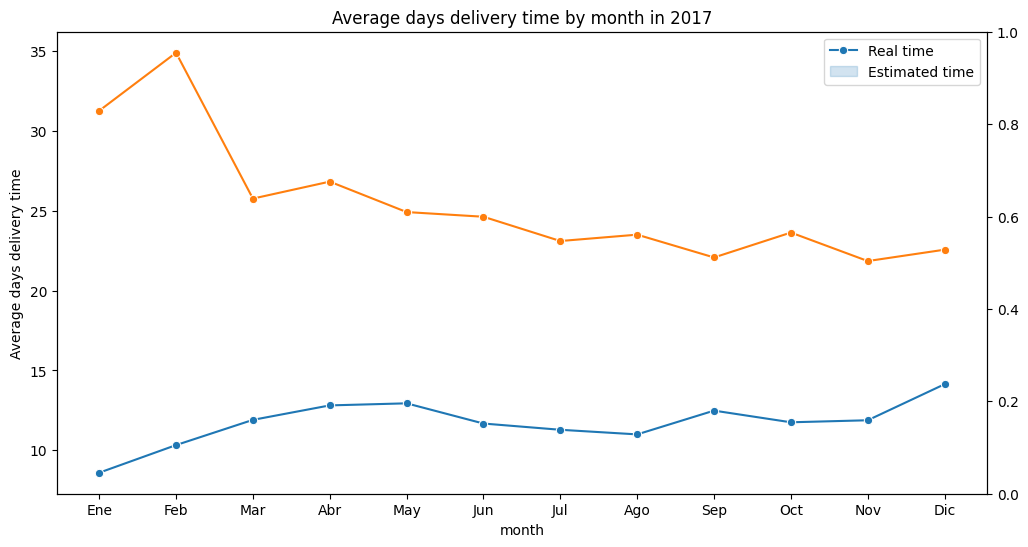

In [177]:
plot_real_vs_predicted_delivered_time(real_vs_estimated_delivered_time, year=2017)

In [178]:
print(global_ammount_order_status.columns)

Index(['order_status', 'Ammount'], dtype='object')


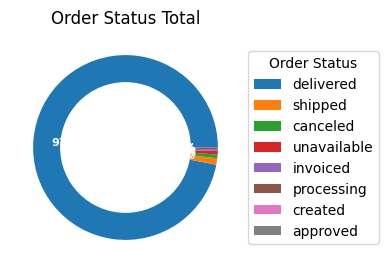

In [179]:
plot_global_amount_order_status(global_ammount_order_status)

In [180]:
plot_orders_per_day_and_holidays_2017(orders_per_day_and_holidays_2017)

NameError: name 'orders_per_day_and_holidays_2017' is not defined

El gráfico de Pedidos por Día y Días Festivos que programarás en **src/plots.py** debe ser similar a este:

![The plot you will code will be similar to this:](images/orders_per_day_and_holidays.png "Orders per Day and Holidays")

4.1 ¿Ves alguna relación entre los días festivos en Brasil durante 2017 y las compras de ese año?

Respuesta: ________

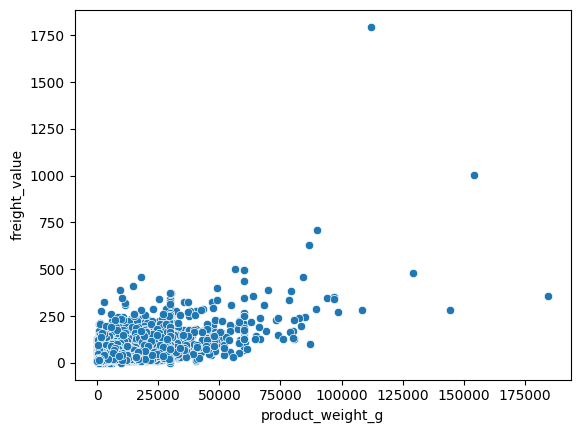

In [ ]:
plot_freight_value_weight_relationship(freight_value_weight_relationship)

El gráfico sobre la relación entre el valor del flete y el peso del producto que debes programar en `src/plots.py` tiene que ser similar a este:

![The plot you will code will be similar to this:](images/freight_value_weight_relationship.png "Freight Value and Weight Relationship")

4.2 ¿Ves alguna correlación entre el valor del flete y el peso del producto?

Respuesta:____